In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import os

In [2]:

# 1. Get weather data
today = datetime.now()
week_ago = today - timedelta(days=7)
start_date = week_ago.strftime("%Y-%m-%d")
end_date = today.strftime("%Y-%m-%d")


In [7]:
# 2. Process with pandas
url = f"https://api.open-meteo.com/v1/forecast?latitude=48.85&longitude=2.35&start_date={start_date}&end_date={end_date}&daily=temperature_2m_max,temperature_2m_min"
response = requests.get(url)
data = response.json()

df = pd.DataFrame({
    'date': pd.to_datetime(data['daily']['time']),
    'max_temp': data['daily']['temperature_2m_max'],
    'min_temp': data['daily']['temperature_2m_min']
})
print(data)
print(df)

{'latitude': 48.84, 'longitude': 2.3599997, 'generationtime_ms': 0.056743621826171875, 'utc_offset_seconds': 0, 'timezone': 'GMT', 'timezone_abbreviation': 'GMT', 'elevation': 46.0, 'daily_units': {'time': 'iso8601', 'temperature_2m_max': '°C', 'temperature_2m_min': '°C'}, 'daily': {'time': ['2026-01-09', '2026-01-10', '2026-01-11', '2026-01-12', '2026-01-13', '2026-01-14', '2026-01-15', '2026-01-16'], 'temperature_2m_max': [9.8, 5.1, 5.1, 11.7, 13.4, 13.1, 13.6, 11.9], 'temperature_2m_min': [5.2, 3.1, 0.2, 4.5, 8.2, 9.1, 8.6, 8.5]}}
        date  max_temp  min_temp
0 2026-01-09       9.8       5.2
1 2026-01-10       5.1       3.1
2 2026-01-11       5.1       0.2
3 2026-01-12      11.7       4.5
4 2026-01-13      13.4       8.2
5 2026-01-14      13.1       9.1
6 2026-01-15      13.6       8.6
7 2026-01-16      11.9       8.5


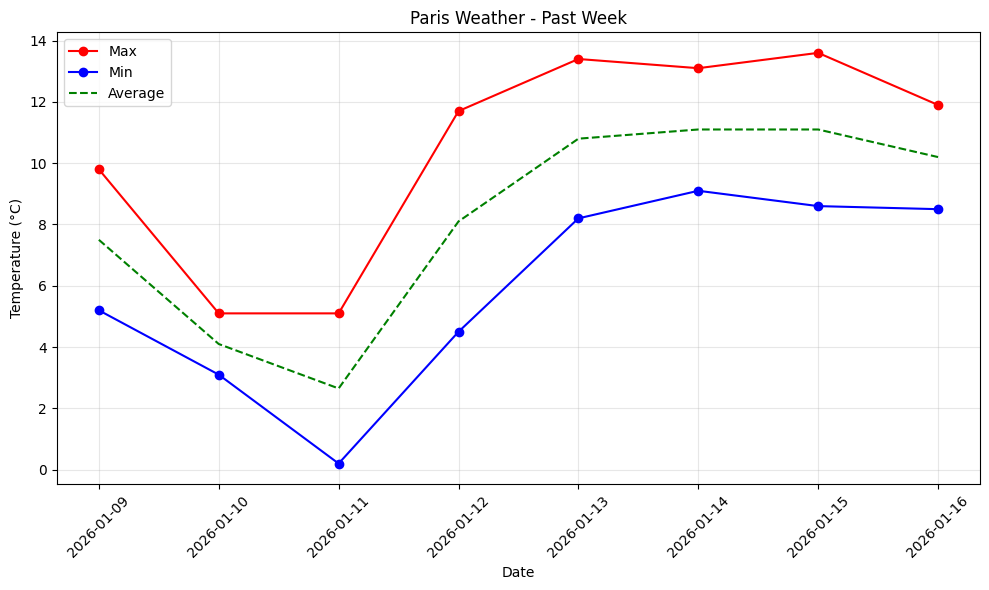

In [ ]:
# 3. Calculate average
df['avg_temp'] = (df['max_temp'] + df['min_temp']) / 2

# 4. Create visualization

#plot data points
plt.figure(figsize=(10, 6))
plt.plot(df['date'], df['max_temp'], 'r-o', label='Max')
plt.plot(df['date'], df['min_temp'], 'b-o', label='Min')
plt.plot(df['date'], df['avg_temp'], 'g--', label='Average')

#make labels pretty
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.title('Paris Weather - Past Week')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

In [5]:
# 5. Save everything
if not os.path.exists('data'):
    os.makedirs('data')

plt.savefig('data/weather_chart.png')
df.to_csv('data/paris_weather.csv', index=False)

print(f"Average temperature: {df['avg_temp'].mean():.1f}°C")
print("Files saved in 'data' folder")

Average temperature: 8.2°C
Files saved in 'data' folder


<Figure size 640x480 with 0 Axes>

In [8]:
print("Current directory:", os.getcwd())

Current directory: f:\Projects\Personal\Python
